In [6]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import timm
from PIL import Image
import torchvision.transforms as transforms
from tqdm import tqdm
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import wandb

wandb.init(
    project='xray-classification',
    name='04b-gradcam-plus',
    config={
        'method': 'GradCAM++',
        'models': ['ResNet50', 'DenseNet121', 'EfficientNet', 'VGG16', 'ConvNeXt'],
        'bbox_images': 880,
        'iou_threshold': 0.5
    }
)
print("✅ Wandb initialized!")

device = torch.device('cuda')
print(f"GPU  : {torch.cuda.get_device_name(0)}")
print(f"Free : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1024**3:.1f}GB")

with open('../data/data_config.pkl', 'rb') as f:
    config = pickle.load(f)

CLASSES    = config['classes']
IMAGE_SIZE = config['image_size']
test_df    = config['test_df']
SEG_DIR    = '../data/segmented_images'

os.makedirs('../results/gradcam_plus', exist_ok=True)

print(f"Classes : {len(CLASSES)}")
print(f"Test    : {len(test_df):,}")
print("✅ Setup done!")

wandb: Currently logged in as: chandinigunna06 (chandinigunna06-iiest-shibpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ Wandb initialized!
GPU  : Tesla V100-PCIE-32GB
Free : 30.8GB
Classes : 15
Test    : 22,424
✅ Setup done!


In [7]:
models = {}

resnet = timm.create_model('resnet50', pretrained=False, num_classes=len(CLASSES))
resnet.load_state_dict(torch.load('../checkpoints/ResNet50/best.pt', map_location=device, weights_only=False)['model_state'])
models['ResNet50'] = resnet.to(device).eval()
print("✅ ResNet50 loaded!")

densenet = timm.create_model('densenet121', pretrained=False, num_classes=len(CLASSES))
densenet.load_state_dict(torch.load('../checkpoints/DenseNet121/best.pt', map_location=device, weights_only=False)['model_state'])
models['DenseNet121'] = densenet.to(device).eval()
print("✅ DenseNet121 loaded!")

efficientnet = timm.create_model('efficientnet_b0', pretrained=False, num_classes=len(CLASSES))
efficientnet.load_state_dict(torch.load('../checkpoints/EfficientNet-B0/best.pt', map_location=device, weights_only=False)['model_state'])
models['EfficientNet'] = efficientnet.to(device).eval()
print("✅ EfficientNet loaded!")

vgg = timm.create_model('vgg16', pretrained=False, num_classes=len(CLASSES))
vgg.load_state_dict(torch.load('../checkpoints/VGG-16/best.pt', map_location=device, weights_only=False)['model_state'])
models['VGG16'] = vgg.to(device).eval()
print("✅ VGG16 loaded!")

convnext = timm.create_model('convnext_base', pretrained=False, num_classes=len(CLASSES))
convnext.load_state_dict(torch.load('../checkpoints/ConvNeXt/best.pt', map_location=device, weights_only=False)['model_state'])
models['ConvNeXt'] = convnext.to(device).eval()
print("✅ ConvNeXt loaded!")

print(f"\n✅ All {len(models)} models loaded! (ViT excluded — GradCAM doesn't apply)")

✅ ResNet50 loaded!
✅ DenseNet121 loaded!
✅ EfficientNet loaded!
✅ VGG16 loaded!
✅ ConvNeXt loaded!

✅ All 5 models loaded! (ViT excluded — GradCAM doesn't apply)


In [8]:
target_layers = {
    'ResNet50':     [models['ResNet50'].layer4[-1]],
    'DenseNet121':  [models['DenseNet121'].features.denseblock4],
    'EfficientNet': [models['EfficientNet'].conv_head],
    'VGG16':        [models['VGG16'].features[-1]],
    'ConvNeXt':     [models['ConvNeXt'].stages[-1].blocks[-1]],
}
print("✅ Target layers defined!")

✅ Target layers defined!


In [9]:
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

bbox_df = pd.read_csv('../data/NIH/BBox_List_2017_Official_NIH.csv')
bbox_df = bbox_df.rename(columns={'Bbox [x': 'x', 'y': 'y', 'w': 'w', 'h]': 'h'})
bbox_df = bbox_df[['Image Index', 'Finding Label', 'x', 'y', 'w', 'h']]

label_map = {'Infiltrate': 'Infiltration'}
bbox_df['Finding Label'] = bbox_df['Finding Label'].replace(label_map)
bbox_df = bbox_df[bbox_df['Finding Label'].isin(CLASSES)].reset_index(drop=True)

ORIGINAL_RES = 1024
scale = IMAGE_SIZE / ORIGINAL_RES
bbox_df['x_scaled'] = bbox_df['x'] * scale
bbox_df['y_scaled'] = bbox_df['y'] * scale
bbox_df['w_scaled'] = bbox_df['w'] * scale
bbox_df['h_scaled'] = bbox_df['h'] * scale

print(f"✅ {len(bbox_df)} bbox annotations ready across {bbox_df['Image Index'].nunique()} images, scale={scale:.4f}")

# Sanity check images exist
missing = [f for f in bbox_df['Image Index'].unique() if not os.path.exists(os.path.join(SEG_DIR, f))]
print(f"Missing images: {len(missing)}")

✅ 984 bbox annotations ready across 880 images, scale=0.2188
Missing images: 0


In [10]:
def cam_to_bbox_mask(grayscale_cam, threshold=0.5):
    return (grayscale_cam >= threshold).astype(np.uint8)

def gt_bbox_to_mask(x, y, w, h, img_size):
    mask = np.zeros((img_size, img_size), dtype=np.uint8)
    x1, y1 = max(0, int(round(x))), max(0, int(round(y)))
    x2, y2 = min(img_size, int(round(x + w))), min(img_size, int(round(y + h)))
    mask[y1:y2, x1:x2] = 1
    return mask

def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return intersection / union if union > 0 else 0.0

print("✅ Helper functions defined!")

✅ Helper functions defined!


In [11]:
iou_results = {model_name: [] for model_name in target_layers}
detailed_records = []

cam_objects = {
    model_name: GradCAMPlusPlus(model=models[model_name], target_layers=target_layers[model_name])
    for model_name in target_layers
}

for idx, row in tqdm(bbox_df.iterrows(), total=len(bbox_df), desc="GradCAM++ + IoU"):
    fname = row['Image Index']
    gt_label = row['Finding Label']
    if gt_label not in CLASSES:
        continue
    gt_class_idx = CLASSES.index(gt_label)

    img_path = os.path.join(SEG_DIR, fname)
    img = Image.open(img_path).convert('RGB')
    input_tensor = val_transform(img).unsqueeze(0).to(device)

    gt_mask = gt_bbox_to_mask(row['x_scaled'], row['y_scaled'], row['w_scaled'], row['h_scaled'], IMAGE_SIZE)

    for model_name, cam in cam_objects.items():
        targets = [ClassifierOutputTarget(gt_class_idx)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
        cam_mask = cam_to_bbox_mask(grayscale_cam, threshold=0.5)
        iou = compute_iou(cam_mask, gt_mask)
        iou_results[model_name].append(iou)
        detailed_records.append({'Image Index': fname, 'Finding Label': gt_label, 'Model': model_name, 'IoU': iou})

    if (idx + 1) % 200 == 0:
        print(f"  ✅ {idx+1}/{len(bbox_df)} processed")

print("\n✅ GradCAM++ + IoU computed for all images and models!")

GradCAM++ + IoU:  20%|█████████████████████████▊                                                                                                     | 200/984 [01:03<03:39,  3.57it/s]

  ✅ 200/984 processed


GradCAM++ + IoU:  41%|███████████████████████████████████████████████████▋                                                                           | 400/984 [01:59<02:50,  3.43it/s]

  ✅ 400/984 processed


GradCAM++ + IoU:  61%|█████████████████████████████████████████████████████████████████████████████▍                                                 | 600/984 [02:56<01:53,  3.39it/s]

  ✅ 600/984 processed


GradCAM++ + IoU:  81%|███████████████████████████████████████████████████████████████████████████████████████████████████████▎                       | 800/984 [03:52<00:50,  3.64it/s]

  ✅ 800/984 processed


GradCAM++ + IoU: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 984/984 [04:46<00:00,  3.44it/s]


✅ GradCAM++ + IoU computed for all images and models!


In [12]:
print("="*60)
print("  GradCAM++ vs Ground-Truth BBox — Mean IoU per Model")
print("="*60)

summary_plus = {}
for model_name, ious in iou_results.items():
    mean_iou = np.mean(ious)
    summary_plus[model_name] = round(mean_iou, 4)
    print(f"{model_name:15s} → Mean IoU: {mean_iou:.4f}  (n={len(ious)})")

best_model = max(summary_plus, key=summary_plus.get)
print("="*60)
print(f"🏆 Best: {best_model} (IoU={summary_plus[best_model]:.4f})")

# Compare against plain GradCAM (04a results)
try:
    with open('../data/gradcam_iou_results.pkl', 'rb') as f:
        gradcam_summary = pickle.load(f)['summary']
    print("\n  Model            GradCAM    GradCAM++   Δ")
    print("  " + "-"*45)
    for m in summary_plus:
        if m in gradcam_summary:
            delta = summary_plus[m] - gradcam_summary[m]
            print(f"  {m:15s}  {gradcam_summary[m]:.4f}    {summary_plus[m]:.4f}    {delta:+.4f}")
except FileNotFoundError:
    print("\n⚠️ 04a results not found — run 04a_gradcam.ipynb first for comparison")

iou_df = pd.DataFrame(detailed_records)

  GradCAM++ vs Ground-Truth BBox — Mean IoU per Model
ResNet50        → Mean IoU: 0.1199  (n=984)
DenseNet121     → Mean IoU: 0.1722  (n=984)
EfficientNet    → Mean IoU: 0.1281  (n=984)
VGG16           → Mean IoU: 0.1806  (n=984)
ConvNeXt        → Mean IoU: 0.1480  (n=984)
🏆 Best: VGG16 (IoU=0.1806)

  Model            GradCAM    GradCAM++   Δ
  ---------------------------------------------
  ResNet50         0.0527    0.1199    +0.0672
  DenseNet121      0.1441    0.1722    +0.0281
  EfficientNet     0.0387    0.1281    +0.0894
  VGG16            0.1216    0.1806    +0.0590
  ConvNeXt         0.1525    0.1480    -0.0045


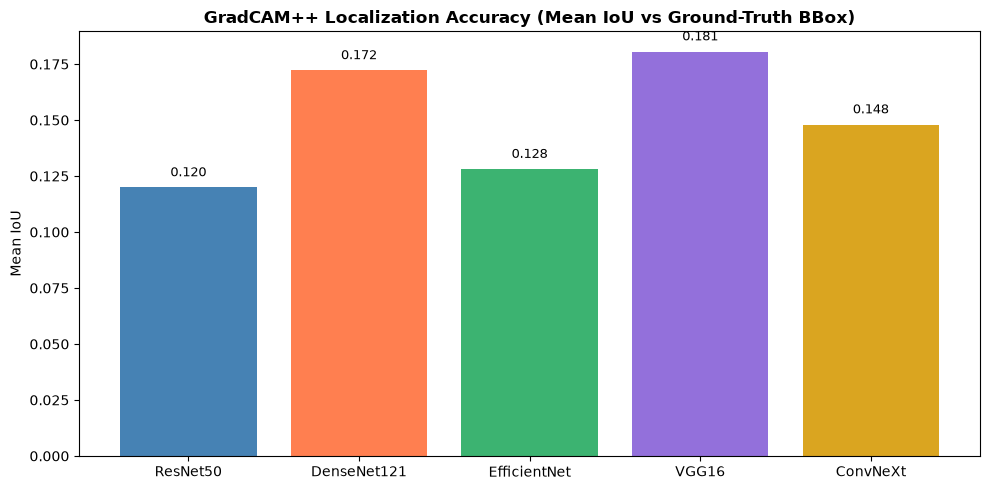

gradcam_plus_best_iou,▁
gradcam_plus_mean_iou_convnext,▁
gradcam_plus_mean_iou_densenet121,▁
gradcam_plus_mean_iou_efficientnet,▁
gradcam_plus_mean_iou_resnet50,▁
gradcam_plus_mean_iou_vgg16,▁
gradcam_plus_best_iou,0.1806
gradcam_plus_best_model,VGG16
gradcam_plus_mean_iou_convnext,0.148
gradcam_plus_mean_iou_densenet121,0.1722
gradcam_plus_mean_iou_efficientnet,0.1281


✅ gradcam_plus_iou_results.pkl saved!
✅ Results logged to wandb!
👉 Next: 04c_attention_rollout.ipynb (ViT)


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
names = list(summary_plus.keys())
values = list(summary_plus.values())
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'goldenrod']
ax.bar(names, values, color=colors)
ax.set_title('GradCAM++ Localization Accuracy (Mean IoU vs Ground-Truth BBox)', fontweight='bold')
ax.set_ylabel('Mean IoU')
for i, v in enumerate(values):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../results/gradcam_plus/gradcam_plus_iou_comparison.png', dpi=150)
plt.show()

with open('../data/gradcam_plus_iou_results.pkl', 'wb') as f:
    pickle.dump({'summary': summary_plus, 'detailed_records': detailed_records, 'iou_df': iou_df}, f)

wandb.log({
    'gradcam_plus_mean_iou_resnet50':     summary_plus.get('ResNet50', 0),
    'gradcam_plus_mean_iou_densenet121':  summary_plus.get('DenseNet121', 0),
    'gradcam_plus_mean_iou_efficientnet': summary_plus.get('EfficientNet', 0),
    'gradcam_plus_mean_iou_vgg16':        summary_plus.get('VGG16', 0),
    'gradcam_plus_mean_iou_convnext':     summary_plus.get('ConvNeXt', 0),
    'gradcam_plus_best_model':            best_model,
    'gradcam_plus_best_iou':              summary_plus[best_model],
    'gradcam_plus_iou_chart':             wandb.Image('../results/gradcam_plus/gradcam_plus_iou_comparison.png')
})
wandb.finish()

print("✅ gradcam_plus_iou_results.pkl saved!")
print("✅ Results logged to wandb!")
print("👉 Next: 04c_attention_rollout.ipynb (ViT)")